# Multimodal Topic Mining and Image Classification
## Advanced Customer Analytics - Visual Data Predictions Assignment


In [ ]:
# Install required packages
# !pip install -q bertopic
# !pip install -q scikit-learn
# !pip install -q pillow
# !pip install -q pandas
# !pip install -q matplotlib
# !pip install -q seaborn
# !pip install -q requests
# !pip install -q tqdm
# !pip install -q datasets
# !pip install -q kaggle


In [8]:
import os
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import zipfile
import subprocess


### Download the dataset and the images

In [9]:
def download_and_process_pokemon_cards(save_dir='pokemon_cards', num_cards=1000):
    """
    Download Pokemon TCG dataset from Kaggle and download card images.
    Everything is saved in a single directory.
    
    Args:
        save_dir: Directory to save everything (images and metadata)
        num_cards: Number of cards to process
        
    Returns:
        df_final: Processed dataframe with image paths
    """
    
    # Create directory structure
    os.makedirs(f"{save_dir}/images", exist_ok=True)
    temp_dir = f"{save_dir}/temp"
    os.makedirs(temp_dir, exist_ok=True)
    
    # Step 1: Download dataset from Kaggle
    print("Downloading Pokemon TCG dataset from Kaggle...")
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'adampq/pokemon-tcg-all-cards-1999-2023', '-p', temp_dir],
        capture_output=True,
        text=True
    )
    
    # Step 2: Extract the dataset
    zip_path = f'{temp_dir}/pokemon-tcg-all-cards-1999-2023.zip'
    if os.path.exists(zip_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
    
    # Step 3: Load the CSV
    csv_files = [f for f in os.listdir(temp_dir) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError("No CSV files found in dataset directory")
    
    cards_file = f'{temp_dir}/{csv_files[0]}'
    df_raw = pd.read_csv(cards_file)
    print(f"Loaded {len(df_raw)} total cards from Kaggle dataset\n")
    
    # Step 4: Download images for subset
    df = df_raw.head(num_cards).copy()
    print(f"Processing {len(df)} cards...")
    
    successful = []
    failed = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Downloading images"):
        try:
            card_id = row['id']
            set_code, number = card_id.split('-')
            
            downloaded = False
            for url_template in [
                f"https://images.pokemontcg.io/{set_code}/{number}_hires.png",
                f"https://images.pokemontcg.io/{set_code}/{number}.png"
            ]:
                try:
                    response = requests.get(url_template, timeout=10)
                    response.raise_for_status()
                    
                    img = Image.open(BytesIO(response.content)).convert('RGB')
                    img_path = f"{save_dir}/images/card_{idx:05d}.jpg"
                    img.save(img_path, 'JPEG', quality=95)
                    
                    df.at[idx, 'image_path'] = img_path
                    successful.append(idx)
                    downloaded = True
                    break
                except:
                    continue
            
            if not downloaded:
                failed.append(card_id)
                
        except Exception as e:
            failed.append(row.get('id', f'idx_{idx}'))
            continue
    
    # Step 5: Save only the final processed dataset
    df_final = df.loc[successful].copy()
    csv_path = f'{save_dir}/pokemon_cards_metadata.csv'
    df_final.to_csv(csv_path, index=False)
    
    # Step 6: Clean up temporary files
    print("\nCleaning up temporary files...")
    import shutil
    shutil.rmtree(temp_dir)
    
    print(f"Successfully processed: {len(df_final)} cards")
    print(f"Failed to download: {len(failed)} cards")
    print(f"Images saved to: {save_dir}/images/")
    print(f"Metadata saved to: {csv_path}")
    
    return df_final

In [ ]:
save_dir = 'pokemon_cards'

# Download and process the dataset
df = download_and_process_pokemon_cards(save_dir, num_cards=1000)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df_radfw.columns)}):")
for col in df.columns:
    print(f"  - {col}")

print(f"\nFirst few rows:")
df.head()

### Load the dataset and preprocess it

In [11]:
# Load the processed data
cards_df = pd.read_csv('./pokemon_cards/pokemon_cards_metadata.csv')

print(f"Dataset shape: {cards_df.shape}")
print(f"\nColumns: {list(cards_df.columns)}")
cards_df.head()

Dataset shape: (1000, 30)

Columns: ['id', 'set', 'series', 'publisher', 'generation', 'release_date', 'artist', 'name', 'set_num', 'types', 'supertype', 'subtypes', 'level', 'hp', 'evolvesFrom', 'evolvesTo', 'abilities', 'attacks', 'weaknesses', 'retreatCost', 'convertedRetreatCost', 'rarity', 'flavorText', 'nationalPokedexNumbers', 'legalities', 'resistances', 'rules', 'regulationMark', 'ancientTrait', 'image_path']


,id,set,series,publisher,generation,release_date,artist,name,set_num,types,...,convertedRetreatCost,rarity,flavorText,nationalPokedexNumbers,legalities,resistances,rules,regulationMark,ancientTrait,image_path
0,base1-1,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Alakazam,1,['Psychic'],...,3.0,Rare Holo,Its brain can outperform a supercomputer. Its ...,[65],{'unlimited': 'Legal'},NaN,NaN,NaN,NaN,pokemon_cards/images/card_00000.jpg
1,base1-2,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Blastoise,2,['Water'],...,3.0,Rare Holo,A brutal Pokémon with pressurized water jets o...,[9],{'unlimited': 'Legal'},NaN,NaN,NaN,NaN,pokemon_cards/images/card_00001.jpg
2,base1-3,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Chansey,3,['Colorless'],...,1.0,Rare Holo,A rare and elusive Pokémon that is said to bri...,[113],{'unlimited': 'Legal'},"[{'type': 'Psychic', 'value': '-30'}]",NaN,NaN,NaN,pokemon_cards/images/card_00002.jpg
3,base1-4,Base,Base,WOTC,First,1/9/1999,Mitsuhiro Arita,Charizard,4,['Fire'],...,3.0,Rare Holo,Spits fire that is hot enough to melt boulders...,[6],{'unlimited': 'Legal'},"[{'type': 'Fighting', 'value': '-30'}]",NaN,NaN,NaN,pokemon_cards/images/card_00003.jpg
4,base1-5,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Clefairy,5,['Colorless'],...,1.0,Rare Holo,Its magical and cute appeal has many admirers....,[35],{'unlimited': 'Legal'},"[{'type': 'Psychic', 'value': '-30'}]",NaN,NaN,NaN,pokemon_cards/images/card_00004.jpg


In [18]:
import ast

def safe_parse_list(value):
    """Convert string representation of list to actual list."""
    if pd.isna(value):
        return None
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return None
    return value

# Parse list columns
list_columns = ['types', 'subtypes', 'retreatCost', 'nationalPokedexNumbers']
for col in list_columns:
    cards_df[f'{col}_parsed'] = cards_df[col].apply(safe_parse_list)

# Extract first type (most important)
cards_df['primary_type'] = cards_df['types_parsed'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

# Extract first subtype
cards_df['primary_subtype'] = cards_df['subtypes_parsed'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

# Convert retreat cost to numeric
cards_df['retreat_cost_count'] = cards_df['retreatCost_parsed'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("Parsed list columns")
cards_df[['name', 'primary_type', 'primary_subtype', 'hp', 'rarity']].head(10)

Parsed list columns


,name,primary_type,primary_subtype,hp,rarity
0,Alakazam,Psychic,Stage 2,80.0,Rare Holo
1,Blastoise,Water,Stage 2,100.0,Rare Holo
2,Chansey,Colorless,Basic,120.0,Rare Holo
3,Charizard,Fire,Stage 2,120.0,Rare Holo
4,Clefairy,Colorless,Basic,40.0,Rare Holo
5,Gyarados,Water,Stage 1,100.0,Rare Holo
6,Hitmonchan,Fighting,Basic,70.0,Rare Holo
7,Machamp,Fighting,Stage 2,100.0,Rare Holo
8,Magneton,Lightning,Stage 1,60.0,Rare Holo
9,Mewtwo,Psychic,Basic,60.0,Rare Holo


In [20]:
# Convert HP to numeric (some might be strings)
cards_df['hp_numeric'] = pd.to_numeric(cards_df['hp'], errors='coerce')

# Count attacks
cards_df['num_attacks'] = cards_df['attacks'].apply(
    lambda x: len(safe_parse_list(x)) if pd.notna(x) else 0
)

# Boolean: has weakness/resistance
cards_df['has_weakness'] = cards_df['weaknesses'].notna()
cards_df['has_resistance'] = cards_df['resistances'].notna()

print("Created numeric features")
cards_df[['name', 'hp_numeric', 'num_attacks', 'retreat_cost_count', 'has_weakness']].head(10)

Created numeric features


,name,hp_numeric,num_attacks,retreat_cost_count,has_weakness
0,Alakazam,80.0,1,3,True
1,Blastoise,100.0,1,3,True
2,Chansey,120.0,2,1,True
3,Charizard,120.0,1,3,True
4,Clefairy,40.0,2,1,True
5,Gyarados,100.0,2,3,True
6,Hitmonchan,70.0,2,2,True
7,Machamp,100.0,1,3,True
8,Magneton,60.0,2,1,True
9,Mewtwo,60.0,2,3,True


In [21]:
# Keep only Pokemon cards (they have types and HP)
pokemon_only = cards_df[
    (cards_df['supertype'] == 'Pokémon') & 
    (cards_df['primary_type'].notna())
].copy()

print(f"Original: {len(cards_df)} cards")
print(f"Pokemon only: {len(pokemon_only)} cards")
print(f"\nType distribution:")
print(pokemon_only['primary_type'].value_counts())

Original: 1000 cards
Pokemon only: 800 cards

Type distribution:
primary_type
Grass        178
Colorless    140
Water        126
Psychic       96
Fighting      93
Lightning     75
Fire          70
Metal         11
Darkness      11
Name: count, dtype: int64


In [27]:
print(f"\nDataset size: {len(pokemon_only)} Pokemon cards")

print(f"\nMissing values in key columns:")
key_cols = ['primary_type', 'hp_numeric', 'rarity', 'artist', 'num_attacks']
for col in key_cols:
    missing = pokemon_only[col].isna().sum()
    pct = (missing / len(pokemon_only)) * 100
    print(f"  {col}: {missing} ({pct:.1f}%)")



Dataset size: 800 Pokemon cards

Missing values in key columns:
  primary_type: 0 (0.0%)
  hp_numeric: 0 (0.0%)
  rarity: 18 (2.2%)
  artist: 0 (0.0%)
  num_attacks: 0 (0.0%)


### Bert implementation

In [66]:
from bertopic import BERTopic
from bertopic.backend import MultiModalBackend
from bertopic.representation import VisualRepresentation
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Create text descriptions for each card
# Combine multiple text fields for richer descriptions
def create_card_description(row):
    """Generate cleaner description without trainer/owner names."""
    parts = []
    
    # Basic Pokemon info - remove trainer prefixes
    if pd.notna(row['name']):
        name = row['name']
        for prefix in ["Blaine's ", "Brock's ", "Misty's ", "Sabrina's ", "Koga's ", 
                       "Erika's ", "Giovanni's ", "Lt. Surge's ", "Rocket's ", "Dark "]:
            name = name.replace(prefix, "")
        parts.append(f"Pokemon: {name}")
    
    # Type and category
    if pd.notna(row['primary_type']):
        parts.append(f"Type: {row['primary_type']}")
    
    if pd.notna(row['primary_subtype']):
        parts.append(f"Evolution stage: {row['primary_subtype']}")
    
    # Stats - categorize HP instead of exact value
    if pd.notna(row['hp_numeric']):
        hp_category = "High HP" if row['hp_numeric'] >= 80 else "Medium HP" if row['hp_numeric'] >= 50 else "Low HP"
        parts.append(hp_category)
    
    # Battle characteristics
    if row['num_attacks'] > 0:
        parts.append(f"{row['num_attacks']} attacks")
    
    if row['retreat_cost_count'] > 0:
        parts.append(f"Retreat cost: {row['retreat_cost_count']}")
    
    # Weakness/Resistance
    if row['has_weakness']:
        parts.append("Has type weakness")
    if row['has_resistance']:
        parts.append("Has type resistance")
    
    return ". ".join(parts)

# Generate descriptions
pokemon_only['description'] = pokemon_only.apply(create_card_description, axis=1)

print(f"Generated descriptions for {len(pokemon_only)} cards")
print("\nSample descriptions:")
for i in range(3):
    print(f"{i+1}. {pokemon_only.iloc[i]['description']}")

Generated descriptions for 800 cards

Sample descriptions:
1. Pokemon: Alakazam. Type: Psychic. Evolution stage: Stage 2. High HP. 1 attacks. Retreat cost: 3. Has type weakness
2. Pokemon: Blastoise. Type: Water. Evolution stage: Stage 2. High HP. 1 attacks. Retreat cost: 3. Has type weakness
3. Pokemon: Chansey. Type: Colorless. Evolution stage: Basic. High HP. 2 attacks. Retreat cost: 1. Has type weakness. Has type resistance


In [67]:
from PIL import Image

def load_image(image_path):
    """Load and return image."""
    try:
        return Image.open(image_path).convert('RGB')
    except Exception as e:
        return None

# Load images
print("Loading images...")
images = []
valid_indices = []

for idx, row in pokemon_only.iterrows():
    img = load_image(row['image_path'])
    if img is not None:
        images.append(img)
        valid_indices.append(idx)

# Filter to only cards with valid images
pokemon_with_images = pokemon_only.loc[valid_indices].reset_index(drop=True)
descriptions = pokemon_with_images['description'].tolist()

print(f"Loaded {len(images)} images successfully")
print(f"Dataset size for BERTopic: {len(pokemon_with_images)} cards")

Loading images...
Loaded 800 images successfully
Dataset size for BERTopic: 800 cards


In [68]:
# Configure the multimodal embedding model
print("Setting up multimodal model...")

# Use CLIP for multimodal embeddings (text + images)
multimodal_model = SentenceTransformer('clip-ViT-B-32')

# Create multimodal backend
multimodal_backend = MultiModalBackend(embedding_model=multimodal_model)

# Configure dimensionality reduction - more conservative settings
umap_model = UMAP(
    n_neighbors=30,      # Increased for larger neighborhoods
    n_components=10,     # Preserve more information
    min_dist=0.1,        # Allow more spreading
    metric='cosine',
    random_state=42
)

# Configure clustering - balanced settings for 12-15 topics
hdbscan_model = HDBSCAN(
    min_cluster_size=20,  # Lowered from 30
    min_samples=5,        # Lowered from 10
    metric='euclidean',
    cluster_selection_epsilon=0.0,
    prediction_data=True
)

# Configure vectorization
vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)
)

print("Model configuration complete")

Setting up multimodal model...
Model configuration complete


In [69]:
# Create BERTopic model
print("Creating BERTopic model...")

topic_model = BERTopic(
    embedding_model=multimodal_backend,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

# Fit the model on both text and images
print("\nFitting BERTopic on multimodal data...")
print("This may take several minutes...")

topics, probs = topic_model.fit_transform(
    documents=descriptions,
    images=images
)

print(f"\nInitial topic modeling complete")
print(f"Initial number of topics: {len(set(topics)) - 1}")

# Reduce to fewer, more meaningful topics
print("\nReducing topics to 10 final topics...")
topic_model.reduce_topics(descriptions, nr_topics=10)

# Get reduced topics
topics = topic_model.topics_

print(f"Final number of topics: {len(set(topics)) - 1}")
print(f"Outliers (topic -1): {sum([1 for t in topics if t == -1])}")

# Add topics to dataframe
pokemon_with_images['topic'] = topics

2025-11-17 20:20:07,768 - BERTopic - Embedding - Transforming documents to embeddings.


Creating BERTopic model...

Fitting BERTopic on multimodal data...
This may take several minutes...


100%|██████████| 25/25 [00:08<00:00,  2.80it/s]
2025-11-17 20:20:18,384 - BERTopic - Embedding - Completed ✓
2025-11-17 20:20:18,384 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-17 20:20:19,727 - BERTopic - Dimensionality - Completed ✓
2025-11-17 20:20:19,727 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-17 20:20:19,738 - BERTopic - Cluster - Completed ✓
2025-11-17 20:20:19,740 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-17 20:20:19,752 - BERTopic - Representation - Completed ✓
2025-11-17 20:20:19,765 - BERTopic - Topic reduction - Reducing number of topics
2025-11-17 20:20:19,768 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-17 20:20:19,775 - BERTopic - Representation - Completed ✓
2025-11-17 20:20:19,776 - BERTopic - Topic reduction - Reduced number of topics from 11 to 10



Initial topic modeling complete
Initial number of topics: 10

Reducing topics to 10 final topics...
Final number of topics: 9
Outliers (topic -1): 89


In [70]:
# EVALUATION: Topic Quality Assessment
print("TOPIC MODELING RESULTS")
print("-" * 80)

# 1. Basic metrics
num_topics = len(set(topics)) - 1
num_outliers = sum([1 for t in topics if t == -1])
outlier_rate = (num_outliers / len(topics)) * 100

print(f"\nNumber of topics discovered: {num_topics}")
print(f"Outliers: {num_outliers}/{len(topics)} ({outlier_rate:.1f}%)")
print(f"Target: 12-18 topics, <10% outliers")

# 2. Topic purity - does each topic represent ONE Pokemon type?
print("\n" + "-" * 80)
print("TOPIC PURITY (Does each topic = one Pokemon type?)")
print("-" * 80)

for topic_id in sorted([t for t in set(topics) if t != -1]):
    topic_cards = pokemon_with_images[pokemon_with_images['topic'] == topic_id]
    type_dist = topic_cards['primary_type'].value_counts(normalize=True) * 100
    
    dominant_type = type_dist.index[0]
    purity = type_dist.iloc[0]
    count = len(topic_cards)
    
    status = "GOOD" if purity >= 80 else "POOR"
    
    print(f"Topic {topic_id:2d}: {dominant_type:12s} - {count:3d} cards - {purity:5.1f}% pure - {status}")
    
    # Show contamination if impure
    if purity < 80 and len(type_dist) > 1:
        contaminant = type_dist.index[1]
        contaminant_pct = type_dist.iloc[1]
        print(f"          WARNING: {contaminant_pct:.1f}% {contaminant} contamination")

# 3. Type coverage - are all Pokemon types represented?
print("\n" + "-" * 80)
print("TYPE COVERAGE (Does every type have a topic?)")
print("-" * 80)

all_types = pokemon_with_images['primary_type'].value_counts()
print(f"\nTotal types in dataset: {len(all_types)}")

for ptype in all_types.index:
    type_cards = pokemon_with_images[pokemon_with_images['primary_type'] == ptype]
    non_outlier_cards = type_cards[type_cards['topic'] != -1]
    
    if len(non_outlier_cards) > 0:
        main_topic = non_outlier_cards['topic'].mode()[0]
        in_topic = sum(non_outlier_cards['topic'] == main_topic)
        coverage = (in_topic / len(type_cards)) * 100
        status = "GOOD" if coverage >= 70 else "POOR"
        print(f"{ptype:12s}: {len(type_cards):3d} cards -> Topic {main_topic:2d} ({coverage:5.1f}% coverage) - {status}")
    else:
        print(f"{ptype:12s}: {len(type_cards):3d} cards -> NO TOPIC (all outliers) - POOR")

# 4. Summary
print("\n" + "-" * 80)
print("SUMMARY")
print("-" * 80)

good_topics = sum([1 for t in set(topics) if t != -1 and 
                   (pokemon_with_images[pokemon_with_images['topic'] == t]['primary_type'].value_counts(normalize=True).iloc[0] * 100) >= 80])
total_topics = num_topics

print(f"Clean topics (>80% purity): {good_topics}/{total_topics}")
print(f"Outlier rate: {outlier_rate:.1f}% (target: <10%)")

if good_topics >= total_topics * 0.8 and outlier_rate < 10:
    print("\nRESULT: EXCELLENT - Topics are clean and well-separated")
elif good_topics >= total_topics * 0.6 and outlier_rate < 15:
    print("\nRESULT: GOOD - Most topics are clean, some mixing")
else:
    print("\nRESULT: NEEDS IMPROVEMENT - Adjust clustering parameters")

TOPIC MODELING RESULTS
--------------------------------------------------------------------------------

Number of topics discovered: 9
Outliers: 89/800 (11.1%)
Target: 12-18 topics, <10% outliers

--------------------------------------------------------------------------------
TOPIC PURITY (Does each topic = one Pokemon type?)
--------------------------------------------------------------------------------
Topic  0: Grass        - 191 cards -  93.2% pure - GOOD
Topic  1: Water        - 147 cards -  80.3% pure - GOOD
Topic  2: Lightning    -  91 cards -  50.5% pure - POOR
Topic  3: Colorless    -  70 cards -  70.0% pure - POOR
Topic  4: Fire         -  68 cards -  94.1% pure - GOOD
Topic  5: Colorless    -  44 cards -  65.9% pure - POOR
Topic  6: Fighting     -  40 cards -  97.5% pure - GOOD
Topic  7: Colorless    -  32 cards -  93.8% pure - GOOD
Topic  8: Fighting     -  28 cards -  96.4% pure - GOOD

--------------------------------------------------------------------------------
TYP

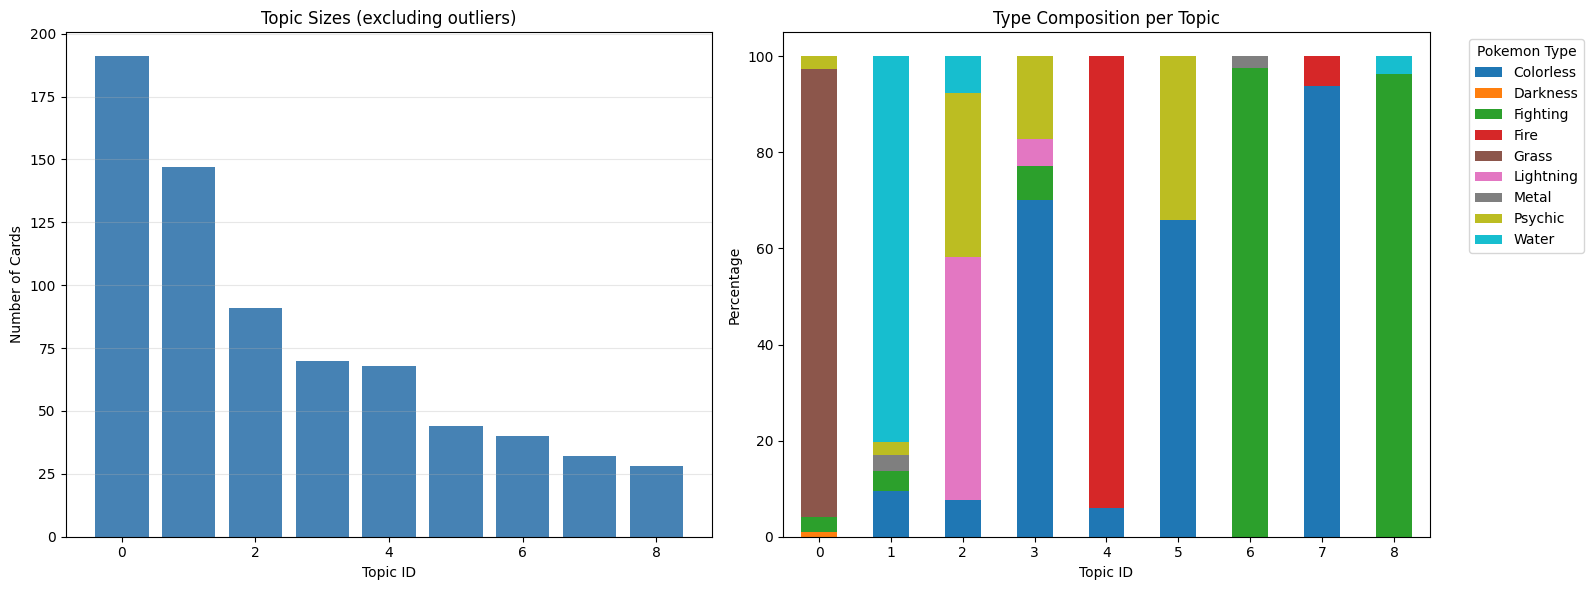

In [71]:
# VISUALIZATION: Topic-Type Alignment
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Topic sizes
topic_counts = pokemon_with_images['topic'].value_counts().sort_index()
topic_counts_no_outliers = topic_counts[topic_counts.index != -1]

axes[0].bar(range(len(topic_counts_no_outliers)), topic_counts_no_outliers.values, color='steelblue')
axes[0].set_xlabel('Topic ID')
axes[0].set_ylabel('Number of Cards')
axes[0].set_title('Topic Sizes (excluding outliers)')
axes[0].grid(axis='y', alpha=0.3)

# Right: Type distribution per topic
topic_type_dist = pd.crosstab(
    pokemon_with_images[pokemon_with_images['topic'] != -1]['topic'],
    pokemon_with_images[pokemon_with_images['topic'] != -1]['primary_type'],
    normalize='index'
) * 100

topic_type_dist.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_xlabel('Topic ID')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Type Composition per Topic')
axes[1].legend(title='Pokemon Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [72]:
# SAMPLE CARDS: What does each topic represent?
print("TOPIC EXAMPLES (First 5 topics)")
print("-" * 80)

for topic_id in range(min(5, len(set(topics)) - 1)):
    topic_cards = pokemon_with_images[pokemon_with_images['topic'] == topic_id]
    
    if len(topic_cards) > 0:
        # Get dominant type
        dominant_type = topic_cards['primary_type'].mode()[0]
        type_pct = (topic_cards['primary_type'] == dominant_type).sum() / len(topic_cards) * 100
        
        print(f"\nTopic {topic_id}: {dominant_type} ({len(topic_cards)} cards, {type_pct:.0f}% purity)")
        print("  Sample cards:")
        for idx, row in topic_cards.head(3).iterrows():
            print(f"    - {row['name']:20s} | Type: {row['primary_type']:10s} | {row['primary_subtype']:8s} | HP: {int(row['hp_numeric']):3d}")
        print()

TOPIC EXAMPLES (First 5 topics)
--------------------------------------------------------------------------------

Topic 0: Grass (191 cards, 93% purity)
  Sample cards:
    - Nidoking             | Type: Grass      | Stage 2  | HP:  90
    - Venusaur             | Type: Grass      | Stage 2  | HP: 100
    - Beedrill             | Type: Grass      | Stage 2  | HP:  80


Topic 1: Water (147 cards, 80% purity)
  Sample cards:
    - Blastoise            | Type: Water      | Stage 2  | HP: 100
    - Gyarados             | Type: Water      | Stage 1  | HP: 100
    - Poliwrath            | Type: Water      | Stage 2  | HP:  90


Topic 2: Lightning (91 cards, 51% purity)
  Sample cards:
    - Alakazam             | Type: Psychic    | Stage 2  | HP:  80
    - Raichu               | Type: Lightning  | Stage 1  | HP:  80
    - Zapdos               | Type: Lightning  | Basic    | HP:  90


Topic 3: Colorless (70 cards, 70% purity)
  Sample cards:
    - Mewtwo               | Type: Psychic    | Bas